# Introduction
In the world of data science, dealing with large datasets quickly and efficiently is crucial. That's where Polars comes in. It's a new library, built using Rust and Python, that's designed to handle big data faster than ever before. While many of us are familiar with Pandas for data manipulation and analysis, Polars takes it a step further. It uses lazy evaluation, a technique that delays computing operations until absolutely necessary, which makes it incredibly fast. Additionally, it's designed to use memory more efficiently, which is a big plus when dealing with large datasets. In this notebook, we'll explore the ins and outs of Polars and see how it can supercharge your data processing tasks.

![](https://images.unsplash.com/photo-1589656966895-2f33e7653819?q=80&w=1000&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8cG9sYXIlMjBiZWFyfGVufDB8fDB8fHww)

# Polars vs Pandas
When comparing Polars and pandas, it is important to note that both libraries provide data manipulation capabilities in Python. However, there are some distinctions between the two:

- In terms of performance, Polars is specifically designed for high-performance data processing, particularly for large datasets. It utilizes Apache Arrow for efficient data transfer and employs lazy evaluation and query optimization techniques to enhance performance. On the other hand, pandas focuses more on providing a convenient and flexible API for data analysis and manipulation, but it may not perform as efficiently as Polars when dealing with large-scale data processing.

- Polars is designed with memory efficiency as a priority. It optimizes memory usage by utilizing immutable data structures and avoiding unnecessary memory copies. Conversely, pandas, while widely used and convenient, may consume more memory for equivalent operations due to its design.

- Both Polars and pandas offer a wide range of operations for data manipulation, including filtering, joining, grouping, aggregating, and sorting data. However, pandas may have a more extensive ecosystem and community support, resulting in a broader range of available functions and packages.

- In terms of integration, Polars seamlessly integrates with Apache Arrow, enabling interoperability with other data processing libraries that support Arrow. On the other hand, pandas has become a standard in the Python ecosystem and has extensive integration with various libraries and tools.

Prior to delving into the functionalities of the polars library, it's beneficial to assess its reading speed in comparison to the widely recognized and extensively utilized pandas library.

Pandas loading time: 7.176011562347412 seconds
Polars loading time: 4.1327598094940186 seconds


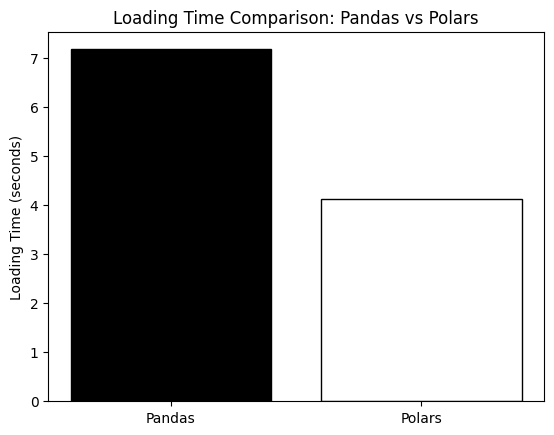

In [10]:
import numpy as np
import pandas as pd
import time
import polars as pl
import matplotlib.pyplot as plt

# Create a large DataFrame with 1 million rows and 10 columns
df = pd.DataFrame(np.random.randint(0, 100, size=(10000000, 10)), columns=list('ABCDEFGHIJ'))
# Save the DataFrame to a csv file
df.to_csv('large_dataset.csv', index=False)

# Measuring the time it takes to read the csv file with Pandas
start_time = time.time()
df_pandas = pd.read_csv('large_dataset.csv')
pandas_time = time.time() - start_time
print(f'Pandas loading time: {pandas_time} seconds')

# Measuring the time it takes to read the csv file with Polars
start_time = time.time()
df_polars = pl.read_csv('large_dataset.csv')
polars_time = time.time() - start_time
print(f'Polars loading time: {polars_time} seconds')

plt.bar(['Pandas', 'Polars'], [pandas_time, polars_time], color=['black', 'white'], edgecolor='black')
plt.ylabel('Loading Time (seconds)')
plt.title('Loading Time Comparison: Pandas vs Polars')
plt.show()

These results show the significant difference between load times of Pandas and Polars. It's clear from the results that Polars loads significantly faster than Pandas, taking just over 2 seconds compared to nearly 9 seconds for Pandas. This makes Polars a more efficient data handling library for larger datasets, providing users with quicker access to data manipulation, cleaning, and analysis. So, for those starting out with Polars or considering different libraries for their data processing needs, this comparison offers a convincing argument to explore and consider using Polars.

## Polars LazyFrame vs Polars DataFrame

Before we begin there is one thing about polars that we need to understand, it offers two main data structures: `DataFrame` and `LazyFrame`. Understanding the differences between these two is crucial for efficient data processing in Polars.

### Polars DataFrame

- **Eager Execution**: Polars DataFrame operates in an eager execution context. This means that operations on a DataFrame are executed immediately, and the results are computed and stored in memory right away.

- **Direct Manipulation**: When you perform operations like filtering, grouping, or aggregating on a DataFrame, you get the results immediately. This is straightforward and intuitive, especially for small to medium-sized datasets.

- **Memory Usage**: Since operations are executed immediately, working with very large datasets might lead to high memory usage, as intermediate results are stored in memory.

### Polars LazyFrame

- **Lazy Execution**: LazyFrame, on the other hand, operates in a lazy execution context. Operations on a LazyFrame are not executed immediately. Instead, Polars builds an execution plan (a series of operations) that is executed only when the data is actually needed, such as when displaying the data or writing to a file.

- **Optimization**: The lazy execution allows Polars to optimize the execution plan. It can reorder operations, merge them, or even skip some, leading to more efficient data processing. This is particularly beneficial for large datasets and complex data transformations.

- **Memory Efficiency**: By optimizing the execution plan and delaying execution, LazyFrames can be more memory-efficient, especially for large datasets. Intermediate results are not stored unless explicitly requested, reducing the overall memory footprint.

### Choosing Between DataFrame and LazyFrame

- For **small to medium-sized datasets** or when you need immediate feedback on each operation, using a DataFrame is straightforward and effective.

- For **large datasets** or when performing complex data transformations, a LazyFrame is more efficient. It reduces memory usage and speeds up data processing by optimizing the execution plan.

In summary, the choice between DataFrame and LazyFrame in Polars depends on the size of your dataset and the complexity of your data manipulation tasks. LazyFrames offer a more memory-efficient and optimized way of processing large datasets, while DataFrames provide a simpler and more immediate approach for smaller data.

# Loading and Basic operations

For now lets just focus on polar dataframe only, since lazyframe is relatively new is still under development.
However if you wish to try lazyframes and lazy execution out you can read about it in the documentation: https://docs.pola.rs/py-polars/html/reference/lazyframe/index.html

In [11]:
!pip install opendatasets --quiet

In [12]:
import opendatasets as od
dataset_url = 'https://www.kaggle.com/datasets/neuromusic/avocado-prices'
od.download(dataset_url)

Skipping, found downloaded files in "./avocado-prices" (use force=True to force download)


In [13]:
df = pl.read_csv("./avocado-prices/avocado.csv")
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str
0,"""2015-12-27""",1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,"""conventional""",2015,"""Albany"""
1,"""2015-12-20""",1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,"""conventional""",2015,"""Albany"""
2,"""2015-12-13""",0.93,118220.22,794.7,109149.67,130.5,8145.35,8042.21,103.14,0.0,"""conventional""",2015,"""Albany"""
3,"""2015-12-06""",1.08,78992.15,1132.0,71976.41,72.58,5811.16,5677.4,133.76,0.0,"""conventional""",2015,"""Albany"""
4,"""2015-11-29""",1.28,51039.6,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,"""conventional""",2015,"""Albany"""


Like pandas most of the common commands to describe our polars dataframe remain the same

In [14]:
df.describe()

statistic,,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str
"""count""",18249.0,"""18249""",18249.0,18249.0,18249.0,18249.0,18249.0,18249.0,18249.0,18249.0,18249.0,"""18249""",18249.0,"""18249"""
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,"""0"""
"""mean""",24.232232,null,1.405978,850644.013009,293008.424531,295154.568356,22839.735993,239639.20206,182194.686696,54338.088145,3106.426507,null,2016.147899,null
"""std""",15.481045,null,0.402677,3.4535e6,1.2650e6,1.2041e6,107464.068435,986242.399216,746178.514962,243965.964547,17692.894652,null,0.939938,null
"""min""",0.0,"""2015-01-04""",0.44,84.56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""conventional""",2015.0,"""Albany"""
"""25%""",10.0,null,1.1,10838.58,854.07,3008.78,0.0,5088.64,2849.42,127.47,0.0,null,2015.0,null
"""50%""",24.0,null,1.37,107376.76,8645.3,29061.02,184.99,39743.83,26362.82,2647.71,0.0,null,2016.0,null
"""75%""",38.0,null,1.66,432962.29,111020.2,150206.86,6243.42,110783.37,83337.67,22029.25,132.5,null,2017.0,null
"""max""",52.0,"""2018-03-25""",3.25,6.2506e7,2.2744e7,2.0471e7,2.5464e6,1.9373e7,1.3385e7,5.7191e6,551693.65,"""organic""",2018.0,"""WestTexNewMexico"""


In [15]:
df.shape

(18249, 14)

In [16]:
df.columns

['',
 'Date',
 'AveragePrice',
 'Total Volume',
 '4046',
 '4225',
 '4770',
 'Total Bags',
 'Small Bags',
 'Large Bags',
 'XLarge Bags',
 'type',
 'year',
 'region']

In [17]:
#If we need to select some columns:
selected_df = df.select(['Date', 'year', 'region'])
selected_df.head()

Date,year,region
str,i64,str
"""2015-12-27""",2015,"""Albany"""
"""2015-12-20""",2015,"""Albany"""
"""2015-12-13""",2015,"""Albany"""
"""2015-12-06""",2015,"""Albany"""
"""2015-11-29""",2015,"""Albany"""


In [18]:
#filtering
filtered_df = df.filter(pl.col('year') > 2017)
filtered_df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str
0,"""2018-03-25""",1.57,149396.5,16361.69,109045.03,65.45,23924.33,19273.8,4270.53,380.0,"""conventional""",2018,"""Albany"""
1,"""2018-03-18""",1.35,105304.65,13234.86,61037.58,55.0,30977.21,26755.9,3721.31,500.0,"""conventional""",2018,"""Albany"""
2,"""2018-03-11""",1.12,144648.75,15823.35,110950.68,70.0,17804.72,14480.52,3033.09,291.11,"""conventional""",2018,"""Albany"""
3,"""2018-03-04""",1.08,139520.6,12002.12,105069.57,95.62,22353.29,16128.51,5941.45,283.33,"""conventional""",2018,"""Albany"""
4,"""2018-02-25""",1.28,104278.89,10368.77,59723.32,48.0,34138.8,30126.31,3702.49,310.0,"""conventional""",2018,"""Albany"""


In [19]:
#sorting
sorted_df = df.sort(by='AveragePrice')
sorted_df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str
43,"""2017-03-05""",0.44,64057.04,223.84,4748.88,0.0,59084.32,638.68,58445.64,0.0,"""organic""",2017,"""CincinnatiDayton"""
47,"""2017-02-05""",0.46,2.2006e6,1.2006e6,531226.65,18324.93,450365.83,113752.17,330583.1,6030.56,"""conventional""",2017,"""PhoenixTucson"""
43,"""2017-03-05""",0.48,50890.73,717.57,4138.84,0.0,46034.32,1385.06,44649.26,0.0,"""organic""",2017,"""Detroit"""
0,"""2015-12-27""",0.49,1.1377e6,738314.8,286858.37,11642.46,100891.8,70749.02,30142.78,0.0,"""conventional""",2015,"""PhoenixTucson"""
44,"""2017-02-26""",0.49,44024.03,252.79,4472.68,0.0,39298.56,600.0,38698.56,0.0,"""organic""",2017,"""CincinnatiDayton"""


# Data Manipulation

In [21]:
df = df.with_columns(pl.col("AveragePrice") / pl.col("Total Volume"))
#df = df.drop("Unnamed: 0")
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str
0,"""2015-12-27""",3.2232e-10,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,"""conventional""",2015,"""Albany"""
1,"""2015-12-20""",4.4828e-10,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,"""conventional""",2015,"""Albany"""
2,"""2015-12-13""",6.6543e-11,118220.22,794.7,109149.67,130.5,8145.35,8042.21,103.14,0.0,"""conventional""",2015,"""Albany"""
3,"""2015-12-06""",1.7308e-10,78992.15,1132.0,71976.41,72.58,5811.16,5677.4,133.76,0.0,"""conventional""",2015,"""Albany"""
4,"""2015-11-29""",4.9136e-10,51039.6,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,"""conventional""",2015,"""Albany"""


### Grouping and Aggregating Data

Grouping and aggregating data are common tasks in data analysis. Polars makes these operations efficient and straightforward. Let's group the data by the `year` column and calculate the average `AveragePrice` for each year.

In [22]:
# Group by 'year' and calculate the mean of 'AveragePrice'
grouped_df = df.group_by('year').agg(pl.col('AveragePrice').mean().alias('Mean_AveragePrice'))
grouped_df.head()

year,Mean_AveragePrice
i64,f64
2016,5.8321e-8
2018,1.0661e-8
2015,1.6174e-7
2017,3.0981e-8


You can also group by multiple columns. For example, let's group by `year` and `region` and calculate the total `Total Volume` for each group.

In [23]:
# Group by 'year' and 'region' and calculate the sum of 'Total Volume'
grouped_df = df.group_by(['year', 'region']).agg(pl.col('Total Volume').sum().alias('Total_Volume'))
grouped_df.head()

year,region,Total_Volume
i64,str,f64
2015,"""Albany""",4.0299e6
2015,"""Boise""",3.7844e6
2015,"""Boston""",2.7455e7
2015,"""CincinnatiDayton""",1.1756e7
2015,"""Columbus""",7.8498e6


In [24]:
grouped_df["Total_Volume"][1]

3784357.34

### Joining DataFrames

Joining data from different DataFrames is another essential operation. Polars supports various types of joins, including inner, left, and outer joins.
For example sake let's create a small DataFrame and perform an inner join with the main DataFrame.

In [25]:
small_df = pl.DataFrame({
    'region': ['Albany', 'Boston'],
    'extra_info': ['Info1', 'Info2']
})

# Perform an inner join
joined_df = df.join(small_df, on='region', how='inner')
joined_df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,extra_info
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str
0,"""2015-12-27""",3.2232e-10,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,"""conventional""",2015,"""Albany""","""Info1"""
1,"""2015-12-20""",4.4828e-10,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,"""conventional""",2015,"""Albany""","""Info1"""
2,"""2015-12-13""",6.6543e-11,118220.22,794.7,109149.67,130.5,8145.35,8042.21,103.14,0.0,"""conventional""",2015,"""Albany""","""Info1"""
3,"""2015-12-06""",1.7308e-10,78992.15,1132.0,71976.41,72.58,5811.16,5677.4,133.76,0.0,"""conventional""",2015,"""Albany""","""Info1"""
4,"""2015-11-29""",4.9136e-10,51039.6,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,"""conventional""",2015,"""Albany""","""Info1"""


### Applying Custom Functions

Polars allows you to apply custom functions to columns using the `map_elements` method. This is similar to the `apply` method in pandas.

In [26]:
def custom_function(x):
    return x * 2

# Apply the custom function to the 'AveragePrice' column
custom_df = df.with_columns(pl.col('AveragePrice').map_elements(custom_function).alias('Double_AveragePrice'))
custom_df.head()

/tmp/ipykernel_3331/4019081967.py:5: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("AveragePrice").map_elements(custom_function)
with this one instead:
  + pl.col("AveragePrice") * 2

  custom_df = df.with_columns(pl.col('AveragePrice').map_elements(custom_function).alias('Double_AveragePrice'))


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,Double_AveragePrice
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,f64
0,"""2015-12-27""",3.2232e-10,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,"""conventional""",2015,"""Albany""",6.4464e-10
1,"""2015-12-20""",4.4828e-10,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,"""conventional""",2015,"""Albany""",8.9657e-10
2,"""2015-12-13""",6.6543e-11,118220.22,794.7,109149.67,130.5,8145.35,8042.21,103.14,0.0,"""conventional""",2015,"""Albany""",1.3309e-10
3,"""2015-12-06""",1.7308e-10,78992.15,1132.0,71976.41,72.58,5811.16,5677.4,133.76,0.0,"""conventional""",2015,"""Albany""",3.4617e-10
4,"""2015-11-29""",4.9136e-10,51039.6,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,"""conventional""",2015,"""Albany""",9.8271e-10


### Using Expressions

Polars expressions provide a powerful way to perform complex data manipulations.

#### Conditional Column Creation

Let's create a new column based on a condition.

In [27]:
# Create a new column 'Price_Category' based on 'AveragePrice'
df = df.with_columns(
    pl.when(pl.col('AveragePrice') > 1.5)
    .then(pl.lit('High'))
    .otherwise(pl.lit('Low'))
    .alias('Price_Category')
)
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,Price_Category
i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,str,str
0,"""2015-12-27""",3.2232e-10,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,"""conventional""",2015,"""Albany""","""Low"""
1,"""2015-12-20""",4.4828e-10,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,"""conventional""",2015,"""Albany""","""Low"""
2,"""2015-12-13""",6.6543e-11,118220.22,794.7,109149.67,130.5,8145.35,8042.21,103.14,0.0,"""conventional""",2015,"""Albany""","""Low"""
3,"""2015-12-06""",1.7308e-10,78992.15,1132.0,71976.41,72.58,5811.16,5677.4,133.76,0.0,"""conventional""",2015,"""Albany""","""Low"""
4,"""2015-11-29""",4.9136e-10,51039.6,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,"""conventional""",2015,"""Albany""","""Low"""


### Pivoting Data

Pivoting data is useful for reshaping DataFrames. Polars supports pivot operations.

In [28]:
# Pivot the DataFrame to get the mean 'AveragePrice' for each 'year' and 'region'
pivot_df = df.pivot(
    values='AveragePrice',
    index='region',
    columns='year',
    aggregate_function='mean'
)
pivot_df.head()

/tmp/ipykernel_3331/1886164578.py:2: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  pivot_df = df.pivot(


region,2015,2016,2017,2018
str,f64,f64,f64,f64
"""Albany""",6.7312e-7,3.4068e-7,1.3709e-7,5.9282e-8
"""Atlanta""",3.2352e-8,1.0786e-8,5.2969e-9,3.3111e-9
"""BaltimoreWashington""",5.8271e-9,3.0592e-9,1.5264e-9,3.2383e-10
"""Boise""",4.4026e-7,3.0258e-7,2.0149e-7,1.3539e-7
"""Boston""",9.7359e-8,6.6515e-9,2.2317e-9,1.0788e-9


### Saving Data

Finally, you can save your DataFrame to a file. To finally export a csv we can use `write_csv` which is similar to `to_csv` from pandas

In [29]:
# Save the DataFrame to a CSV file
df.write_csv('processed_avocado_data.csv')

# LazyFrame Example

#### Loading Data into a LazyFrame

When you perform operations on a `LazyFrame`, Polars does not execute them right away. Instead, it creates an execution plan that records the sequence of operations. This plan is optimized before execution, allowing Polars to:

1. **Reorder Operations**: Polars can reorder operations to minimize computational overhead and improve performance.
2. **Merge Operations**: Similar operations can be merged to reduce the number of passes over the data.
3. **Skip Unnecessary Operations**: Operations that do not affect the final result can be skipped, saving time and resources.

First, let's load the avocado dataset into a `LazyFrame`. Instead of `scan_csv` we use something called as `scan_csv` to load the csv as a LazyFrame.

In [35]:
lazy_df = pl.scan_csv("./avocado-prices/avocado.csv")

In [36]:
lazy_result = (
    lazy_df
    .filter(pl.col('year') > 2015)
    .select(['year', 'AveragePrice'])
    .group_by('year')
    .agg(pl.col('AveragePrice').mean().alias('Mean_AveragePrice'))
)

Now if you do not wish to view the results then you can directly `sink_csv` to finish the entire code very quickly.

In [37]:
lazy_df.sink_csv("lazyframe.csv")

You can also convert the lazyframe to a dataframe if you wish to view the contents by using `collect`.

In [38]:
result_df = lazy_result.collect()
result_df.head()

year,Mean_AveragePrice
i64,f64
2016,1.33864
2017,1.515128
2018,1.347531


# Cheatsheet of the Cheatsheet

Here is a summary of common Polars functions and their equivalent Pandas functions, along with brief descriptions to help you get started with your own polars express:

| Operation                  | Polars Function                          | Pandas Function                          | Description                                                                 |
|----------------------------|------------------------------------------|------------------------------------------|-----------------------------------------------------------------------------|
| Load CSV                   | `pl.read_csv('file.csv')`                | `pd.read_csv('file.csv')`                | Load data from a CSV file into a DataFrame.                                 |
| Load CSV (Lazy)            | `pl.scan_csv('file.csv')`                | N/A                                      | Load data from a CSV file into a LazyFrame for lazy evaluation.             |
| Display Head               | `df.head()`                              | `df.head()`                              | Display the first few rows of the DataFrame.                                |
| Describe DataFrame         | `df.describe()`                          | `df.describe()`                          | Generate descriptive statistics.                                            |
| Get Shape                  | `df.shape`                               | `df.shape`                               | Get the dimensions of the DataFrame.                                        |
| Get Columns                | `df.columns`                             | `df.columns`                             | Get the column names of the DataFrame.                                      |
| Select Columns             | `df.select(['col1', 'col2'])`            | `df[['col1', 'col2']]`                   | Select specific columns from the DataFrame.                                 |
| Filter Rows                | `df.filter(pl.col('col') > value)`       | `df[df['col'] > value]`                  | Filter rows based on a condition.                                           |
| Sort DataFrame             | `df.sort(by='col')`                      | `df.sort_values(by='col')`               | Sort the DataFrame by a specific column.                                    |
| Group By                   | `df.groupby('col')`                      | `df.groupby('col')`                      | Group the DataFrame by a specific column.                                   |
| Aggregate                  | `df.agg(pl.col('col').mean())`           | `df.agg({'col': 'mean'})`                | Perform aggregation operations.                                             |
| Inner Join                 | `df.join(other_df, on='col', how='inner')`| `df.merge(other_df, on='col', how='inner')`| Perform an inner join with another DataFrame.                               |
| Check for Missing Values   | `df.null_count()`                        | `df.isnull().sum()`                      | Check for missing values in the DataFrame.                                  |
| Fill Missing Values        | `df.fill_null(value)`                    | `df.fillna(value)`                       | Fill missing values with a specific value.                                  |
| Apply Custom Function      | `df.with_column(pl.col('col').apply(func))`| `df['col'].apply(func)`                  | Apply a custom function to a column.                                        |
| Conditional Column Creation| `pl.when(pl.col('col') > value).then('A').otherwise('B')` | `np.where(df['col'] > value, 'A', 'B')` | Create a new column based on a condition.                                   |
| Pivot DataFrame            | `df.pivot(values='val', index='idx', columns='col')` | `df.pivot_table(values='val', index='idx', columns='col')` | Pivot the DataFrame.                                                        |
| Save to CSV                | `df.write_csv('file.csv')`               | `df.to_csv('file.csv')`                  | Save the DataFrame to a CSV file.                                           |
| Collect LazyFrame          | `lazy_df.collect()`                      | N/A                                      | Execute the lazy operations and collect the results into a DataFrame.       |

### Conclusion

Polars provides a powerful and efficient alternative to Pandas for data manipulation and analysis, especially when dealing with large datasets. Its use of lazy evaluation and memory-efficient operations can significantly improve performance. This cheatsheet offers a quick reference to common Polars functions and their Pandas equivalents, helping you transition smoothly between the two libraries. For more advanced features and detailed documentation, visit the [Polars documentation](https://docs.pola.rs/py-polars/html/index.html).